In [23]:
from langgraph.graph import StateGraph, START, END 
from typing import TypedDict, Annotated, List, Literal
from pydantic import BaseModel, Field
from langchain_ollama import ChatOllama
import operator
from langchain.messages import HumanMessage, SystemMessage

In [24]:
class interview_state(TypedDict):
     
    resume:str
    jd:str
    resume_st:dict
    jd_st:dict
    matching:dict
    decision:Literal["eligible", "not_eligible"]
    not_matched_replys:str
    
    skils_required:List[str]

    used_basic_skills:Annotated[List[str], operator.add]
    used_moderate_skills:Annotated[List[str], operator.add]
    used_hard_skills:Annotated[List[str], operator.add]

    question:str
    answer: str
    score: Annotated[List[int], operator.add]
    feedback:Annotated[List["str"], operator.add]
    
    basic_iteration:int
    max_iteration:int

    final_feedback:str
    avg_score:int

In [25]:
class ResumeData(BaseModel):
    skills: List[str] = Field(
        description="List of technical and relevant skills mentioned in the resume")
    experience_years: float = Field(
        description="Total years of professional experience (numeric value only)")
    projects: List[str] = Field(
        description="List of key projects mentioned in the resume")
    education: List[str] = Field(
        description="Educational qualifications mentioned in the resume")


#########################################################################################################################################################################
class JDData(BaseModel):
    required_skills: List[str] = Field(
        description="List of key skills required for the job")
    min_experience: float = Field(
        description="Minimum years of experience required for the job")
    role: str = Field(
        description="Job role or title")
    responsibilities: List[str] = Field(
        description="Main responsibilities mentioned in the job description")

###########################################################################################################################################################################################################

class matching_data(BaseModel):
    matched_score: int = Field(
        description="Match score between 0 to 100 based on how well the resume fits the job description")
    matched_skills: List[str] = Field(
        description="List of skills that are present in both resume and job description")
    missing_skills: List[str] = Field(
        description="List of important skills required in the job description but missing in the resume")
    decision: Literal["eligible", "not_eligible"] = Field(
        description="Return 'eligible' if the candidate is a good fit (high match score), otherwise return 'not_eligible'")
    reason: str = Field(
        description="Provide a clear explanation for the decision, including skill match and gaps")
    
model= ChatOllama(
    model="gemma4:e4b",
    temperature=1,
    top_k=64,
    top_p=0.95
)
resumedata=model.with_structured_output(ResumeData)
jddatam=model.with_structured_output(JDData)
matchingdatam=model.with_structured_output(matching_data)

In [26]:
def resume_s(state:  interview_state):
    prompt=f"""
    You are an expert resume parser.
Your task is to extract structured information from the given resume text.
Resume Text: {state["resume"]}
Instructions:
- Extract only the information that is explicitly present in the resume
- Do NOT assume or add any information
- If a field is missing, return an empty list [] or 0 for numbers
- Keep the output clean and structured
Extract the following fields:
1. skills:
- List all technical and relevant skills (e.g., Python, SQL, Machine Learning)
2. experience_years:
- Total years of professional experience (only numeric value, e.g., 2, 3.5)
3. projects:
- List of key projects mentioned in the resume
4. education:
- List of educational qualifications (degree, field, or institution if available)
Output Instructions:
- Return ONLY structured output matching the schema
- Do NOT include any explanation or extra text"""
    
    response= resumedata.invoke(prompt)
    return {"resume_st": response.model_dump()}

#########################################################################################################################################################

def jd_s(state:  interview_state):
    prompt=f"""You are an expert job description (JD) parser.
Your task is to extract structured information from the given job description.
Job Description: {state["jd"]}
Instructions:
- Extract only the information that is explicitly mentioned in the job description
- Do NOT assume or add any information
- If a field is missing, return an empty list [] or 0 for numbers
- Keep the output clean and structured

Extract the following fields:

1. required_skills:
- List all mandatory or required skills mentioned (e.g., Python, SQL, Machine Learning)

2. min_experience:
- Minimum years of experience required (only numeric value, e.g., 2, 3.5)

3. role:
- Job title or role (e.g., Data Scientist, Backend Developer)

4. responsibilities:
- List the main responsibilities or duties mentioned in the job description

Output Instructions:
- Return ONLY structured output matching the schema
- Do NOT include any explanation or extra text"""
    response=jddatam.invoke(prompt)
    return {"jd_st": response.model_dump(),
            "skils_required":[response.required_skills]}

#######################################################################################################################

def matching(state:interview_state):
    prompt=f"""You are an expert hiring assistant.

Your task is to evaluate how well a candidate's resume matches a given job description.
Resume Data: {state["resume_st"]}
Job Description Data: {state["jd_st"]}
Instructions:
- Compare the candidate's skills with the required skills
- Identify which skills match and which are missing
- Compare the candidate's experience with the minimum required experience
- Do NOT assume any information that is not present
Evaluation Criteria:
1. Skills Match:
   - Count how many required skills are present in the resume
2. Missing Skills:
   - Identify important skills from JD that are not present in the resume
3. Experience Match:
   - Check if candidate's experience is greater than or equal to required experience
4. Overall Match Score:
   - Give a score between 0 to 100 based on:
     - Skills match (major weight)
     - Experience match (moderate weight)
Decision Rules:
- If match_score >= 70 → "eligible"
- If match_score < 70 → "not_eligible"
Output Instructions:
- Return ONLY structured output
- Do NOT include any explanation outside the schema
Output Format:
- matched_score: integer (0–100)
- matched_skills: list of matched skills
- missing_skills: list of missing skills
- decision: "eligible" or "not_eligible"
- reason: clear explanation based on skills and experience"""
    response=matchingdatam.invoke(prompt)
    return {"matching": response.model_dump(), "decision": response.decision }

#######################################################################################################

def not_matched_reply(state:interview_state):
    prompt=f"""You are an expert career advisor.
Your task is to analyze the evaluation result of a candidate and explain why the candidate is not a good match for the job.
Evaluation Data: {state["matching"]}
Instructions:
- Clearly explain the gaps between the candidate and the job requirements
- Focus on:
  1. Missing skills
  2. Skill mismatches (if any)
  3. Experience gap (compare candidate vs required experience)
- Do NOT assume anything beyond the provided data
- Use simple and clear language
Output Requirements:
- Write a structured and easy-to-understand explanation
- Mention missing skills explicitly
- Mention if experience is less than required
- Be constructive and helpful (not harsh)
Tone:
- Professional and supportive
Return only the final explanation."""
    
    response=model.invoke(prompt).content
    return {"not_matched_replys": response}

In [27]:
def conditional_fun(state: interview_state) -> Literal["gen_basic_question", "not_matched_reply"]:
    if state["decision"] == "eligible":
        return "gen_basic_question"
    else:
        return "not_matched_reply"

In [28]:
class Eval(BaseModel):
    score: int = Field(description="Score between 0 to 100 based on correctness, clarity, and completeness")
    feedback: str = Field(description="Short constructive feedback. If answer is correct, return empty string ''")

In [29]:
eval_st_m=model.with_structured_output(Eval)

In [30]:
class GenBasicAskQuestionSt(BaseModel):
    question: str = Field(description="Interview question based on one skill")
    used_basic_skill: str = Field(
        description="The single skill from which this question was generated (must be exactly one skill name from input list)"
    )

In [31]:
basic_question_st_m=model.with_structured_output(GenBasicAskQuestionSt)

In [32]:
def gen_basic_question(state: interview_state):
    used_basic_skills = state["used_basic_skills"]
    prompt = [
        SystemMessage(content="""
You are an expert AI interviewer.
You generate high-quality interview questions.
You must strictly follow instructions and avoid repetition.
"""),
        HumanMessage(content=f"""
Generate ONLY ONE basic-level interview question.
Based on these skills:
{state['skils_required']}
IMPORTANT:
- Do NOT use any skill from this list of already used skills:
{used_basic_skills}
Rules:
- Choose ONLY ONE NEW skill (not in used skills list)
- Do NOT repeat any previous skill
- Question must be simple and beginner level
- Return ONLY one question
""")
    ]
    response = basic_question_st_m.invoke(prompt)
    return {
        "question": response.question,
        "used_basic_skills": [response.used_basic_skill]
    }

In [33]:
def ask_basic_question(state: interview_state):
    question = state["question"]
    print("\n" + question)
    answer = input("Your Answer: ")
    return {"answer": answer}

In [34]:
def evaluate_basic_question(state: interview_state):
    basic_iteration = state.get("basic_iteration", 0)

    prompt = [SystemMessage(content="""
You are an expert technical interviewer.
You evaluate answers strictly based on correctness, clarity, and relevance.
Return score between 0 to 100 and short feedback.
"""),
    HumanMessage(content=f"""
Question: {state['question']}
Answer: {state['answer']}
Evaluate the answer properly.
""")]
    iteration= basic_iteration + 1
    response = eval_st_m.invoke(prompt)
    return {
        "score": [response.score],
        "feedback": [response.feedback],
        "basic_iteration": iteration
    }

In [35]:
def condition1(state: interview_state):
    if state.get("basic_iteration", 0) >= state.get("max_iteration", 4):
        return "gen_moderate_question"
    else:
        return "basic_question_generator"

In [37]:
class GenmoderateAskQuestionSt(BaseModel):
    question: str = Field(description="Interview question based on one skill")
    used_moderate_skill: str = Field(
        description="The single skill from which this question was generated (must be exactly one skill name from input list)"
    )

moderate_question_st_m=model.with_structured_output(GenmoderateAskQuestionSt)

########################################################################################################################
def gen_moderate_question(state: interview_state):
    used_moderate_skills = state["used_moderate_skills"]
    prompt = [
        SystemMessage(content="""
You are an expert AI interviewer.
You generate high-quality interview questions.
You must strictly follow instructions and avoid repetition.
"""),
        HumanMessage(content=f"""
Generate ONLY ONE moderate-level interview question.
Based on these skills:
{state['skils_required']}
IMPORTANT:
- Do NOT use any skill from this list of already used skills:
{used_moderate_skills}
Rules:
- Choose ONLY ONE NEW skill (not in used skills list)
- Do NOT repeat any previous skill
- Question must be simple and beginner level
- Return ONLY one question
""")
    ]
    response = moderate_question_st_m.invoke(prompt)
    return {
        "question": response.question,
        "used_moderate_skills": [response.used_moderate_skill]
    }

def ask_moderate_question(state: interview_state):
    question = state["question"]
    print("\n" + question)
    answer = input("Your Answer: ")
    return {"answer": answer}

##################################################################
def evaluate_moderate_question(state: interview_state):
    basic_iteration = state.get("basic_iteration", 0)
    prompt = [SystemMessage(content="""
You are an expert technical interviewer.
You evaluate answers strictly based on correctness, clarity, and relevance.
Return score between 0 to 100 and short feedback.
"""),
    HumanMessage(content=f"""
Question: {state['question']}
Answer: {state['answer']}
Evaluate the answer properly.
""")]
    iteration= basic_iteration + 1
    response = eval_st_m.invoke(prompt)
    return {
        "score": [response.score],
        "feedback": [response.feedback],
        "basic_iteration": iteration
    }


########################################################################################
def condition2(state: interview_state):

    if state.get("basic_iteration", 0) >= state.get("max_iteration", 8):
        return "gen_hard_question"
    else:
        return "moderate_question_generator"

In [38]:
class GenhardAskQuestionSt(BaseModel):
    question: str = Field(description="Interview question based on one skill")

    used_hard_skill: str = Field(
        description="The single skill from which this question was generated (must be exactly one skill name from input list)"
    )

hard_question_st_m=model.with_structured_output(GenhardAskQuestionSt)


def gen_hard_question(state: interview_state):
    used_hard_skills = state["used_hard_skills"]
    prompt = [
        SystemMessage(content="""
You are an expert AI interviewer.
You generate high-quality interview questions.
You must strictly follow instructions and avoid repetition.
"""),
        HumanMessage(content=f"""
Generate ONLY ONE hard-level interview question.

Based on these skills:
{state['skils_required']}

IMPORTANT:
- Do NOT use any skill from this list of already used skills:
{used_hard_skills}

Rules:
- Choose ONLY ONE NEW skill (not in used skills list)
- Do NOT repeat any previous skill
- Question must be simple and beginner level
- Return ONLY one question
""")
    ]

    response = hard_question_st_m.invoke(prompt)

    return {
        "question": response.question,
        "used_hard_skills": [response.used_hard_skill]
    }

############################################################################

def ask_hard_question(state: interview_state):
    question = state["question"]
    print("\n" + question)
    answer = input("Your Answer: ")
    return {"answer": answer}


#########################################################################
def evaluate_hard_question(state: interview_state):
    basic_iteration = state.get("basic_iteration", 0)
    prompt = [SystemMessage(content="""
You are an expert technical interviewer.
You evaluate answers strictly based on correctness, clarity, and relevance.
Return score between 0 to 100 and short feedback.
"""),
    HumanMessage(content=f"""
Question: {state['question']}
Answer: {state['answer']}
Evaluate the answer properly.
""")]
    iteration= basic_iteration + 1

    response = eval_st_m.invoke(prompt)

    return {
        "score": [response.score],
        "feedback": [response.feedback],
        "basic_iteration": iteration
    }

########################################################################################
def condition3(state: interview_state):

    if state.get("basic_iteration", 0) >= state.get("max_iteration", 12):
        return "final_node"
    else:
        return "hard_question_generator"

In [39]:
def final_node(state: interview_state):

    scores = state["score"]
    feedbacks = state["feedback"]    
    if len(scores) > 0:
        avg_score = sum(scores) / len(scores)
    else:
        avg_score = 0

    prompt = [
        SystemMessage(content="""
You are a senior AI interviewer.

Combine all feedback into one final feedback.
- Appreciate good answers
- Mention weak areas
- Give improvement suggestion
- Keep it short and professional
"""),

        HumanMessage(content=f"""
All feedbacks:
{feedbacks}

Generate final feedback.
""")
    ]

    response = model.invoke(prompt).content
    return {
        "avg_score": avg_score,
        "final_feedback": response}

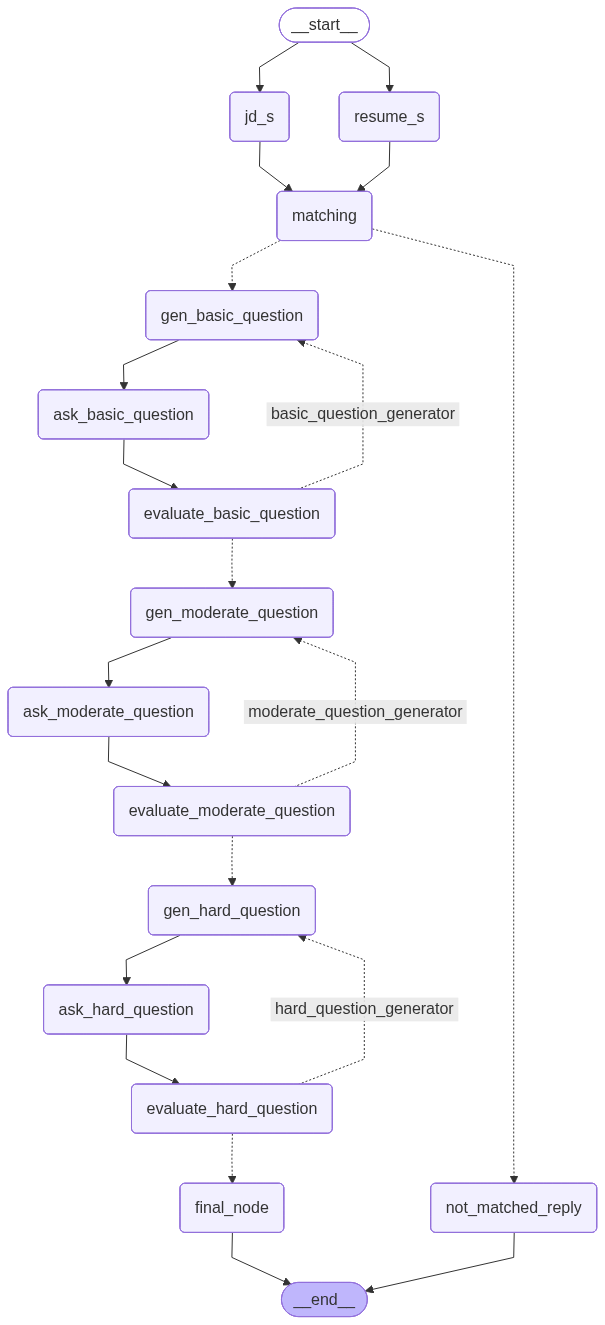

In [40]:
graph=StateGraph(interview_state)

graph.add_node("resume_s", resume_s)
graph.add_node("jd_s", jd_s)
graph.add_node("matching", matching)
graph.add_node("not_matched_reply", not_matched_reply)
# for question generation node
graph.add_node("gen_basic_question", gen_basic_question)
graph.add_node("ask_basic_question", ask_basic_question)
graph.add_node("evaluate_basic_question", evaluate_basic_question)

graph.add_node("gen_moderate_question", gen_moderate_question)
graph.add_node("ask_moderate_question", ask_moderate_question)
graph.add_node("evaluate_moderate_question", evaluate_moderate_question)

graph.add_node("gen_hard_question", gen_hard_question)
graph.add_node("ask_hard_question", ask_hard_question)
graph.add_node("evaluate_hard_question", evaluate_hard_question)


graph.add_node("final_node", final_node)


graph.add_edge(START, "resume_s")
graph.add_edge(START, "jd_s")
graph.add_edge("resume_s", "matching")
graph.add_edge("jd_s", "matching")
graph.add_conditional_edges("matching", conditional_fun)
graph.add_edge("not_matched_reply", END)


# edges for question generation
graph.add_edge("gen_basic_question", "ask_basic_question")
graph.add_edge("ask_basic_question", "evaluate_basic_question")
graph.add_conditional_edges("evaluate_basic_question", condition1, {"basic_question_generator": "gen_basic_question", "gen_moderate_question": "gen_moderate_question"} )

graph.add_edge("gen_moderate_question", "ask_moderate_question")
graph.add_edge("ask_moderate_question", "evaluate_moderate_question")
graph.add_conditional_edges("evaluate_moderate_question",condition2, {"gen_hard_question": "gen_hard_question", "moderate_question_generator":"gen_moderate_question"})

graph.add_edge("gen_hard_question", "ask_hard_question")
graph.add_edge("ask_hard_question", "evaluate_hard_question")
graph.add_conditional_edges("evaluate_hard_question",condition3, {"final_node": "final_node", "hard_question_generator":"gen_hard_question"})
graph.add_edge("final_node", END)



workflow=graph.compile()
workflow



In [41]:
intial_state={"resume":resume,  "jd": jd}
response1=workflow.invoke(intial_state)


What is the primary use case for a relational database like SQL, and what is the difference between a primary key and a foreign key?

Can you explain, in simple terms, what a Central Limit Theorem is and why it's important in data analysis?

In Python, what is the difference between a list and a tuple, and when would you use each?

Can you briefly explain what a vector database is and give an example of when it would be useful?

Imagine you're working on a project that requires data visualization. If you needed to select the appropriate type of graph (e.g., bar, line, scatter) to illustrate a simple relationship between two variables, what factors would you consider to make the most effective choice?

If you were asked to estimate the variability of a process using data, what foundational statistical concept would you calculate, and why is this metric crucial for understanding data spread?

If you needed to connect a Python script to a structured database like Postgres to fetch user d

In [42]:
response1

{'resume': 'Name: Rahul Sharma\nLocation: Remote\nEmail: rahul.sharma.ai@email.com\nExperience: 1.5 Years\n\nProfessional Summary:\nResults-driven AI/ML enthusiast with 1.5 years of experience in developing intelligent applications. Specialized in building multi-agent systems using LangGraph and developing robust Retrieval-Augmented Generation (RAG) pipelines. Strong foundation in statistics and data visualization, with a proven track record of optimizing AI workflows.\n\nTechnical Skills:\n\nProgramming: Python, SQL\n\nAI/ML Frameworks: LangChain, LangGraph, Custom LLM Integration, Llama-3, Qwen\n\nDatabases & Vector Stores: ChromaDB, PostgreSQL\n\nData Visualization & BI: Power BI, DAX Formulas, Interactive Dashboards\n\nStatistics: Probability Distributions, Standard Deviation, Central Limit Theorem\n\nKey Projects & Experience:\n\nMulti-Agent Resume Screening System: Built an automated HR tool using LangGraph and LangChain to screen candidate resumes against JD criteria with 95% ac

In [46]:
response1["score"]

[100, 98, 100, 100, 95, 100, 100, 100, 95, 0, 20, 0]

In [48]:
intial_state={"resume":resume2,  "jd": jd}
response2=workflow.invoke(intial_state)

In [49]:
response2

{'resume': 'Name: Vikram Singh\nLocation: Hybrid\nEmail: vikram.data@email.com\nExperience: 1 Year\n\nProfessional Summary:\nDetail-oriented Data Analyst and aspiring Data Scientist with 1 year of experience in analyzing complex datasets and building predictive machine learning models. Passionate about leveraging data to drive business decisions and improve customer engagement.\n\nTechnical Skills:\n\nProgramming: Python, R, SQL\n\nMachine Learning: Scikit-Learn, Pandas, NumPy, XGBoost\n\nDatabases: MySQL, MongoDB\n\nData Visualization: Tableau, Matplotlib, Seaborn\n\nStatistics: Basic Probability, Hypothesis Testing, A/B Testing\n\nKey Projects & Experience:\n\nCustomer Churn Prediction Model: Developed a Random Forest classification model using Scikit-Learn to predict customer churn with 85% accuracy.\n\nRetail Sales Analysis: Cleaned and analyzed over 50,000 rows of retail data using Python (Pandas) and SQL to identify seasonal purchasing trends.\n\nInteractive Data Reports: Created

In [50]:
response2["decision"]

'not_eligible'

In [22]:
jd="""Job Title: Associate Data Scientist (AI/ML)
Location: Remote / Hybrid
Experience: 0-2 Years (Candidates with strong project portfolios are encouraged to apply)
Job Type: Full-Time

About the Role:
We are looking for an enthusiastic Associate Data Scientist to join our AI innovation team. You will be responsible for developing intelligent applications, analyzing complex datasets, and building multi-agent systems to solve real-world business problems. The ideal candidate has a strong foundation in statistics, machine learning, and modern LLM frameworks.

Key Responsibilities:

Design, develop, and deploy AI-driven applications using Large Language Models (LLMs).

Build robust Retrieval-Augmented Generation (RAG) pipelines for document processing and conversational AI.

Analyze business data and create interactive, executive-level dashboards to track key performance indicators.

Apply statistical concepts to customer segmentation and predictive modeling.

Collaborate with the engineering team to optimize model performance and inference speed on high-end GPUs.

Required Technical Skills:

Programming Languages: Proficiency in Python.

AI/ML Frameworks: Hands-on experience with LangChain, LangGraph, and integrating custom/open-source LLMs.

Data Visualization: Experience with Power BI, DAX formulas, and creating comprehensive sales or analytics reports.

Databases: Familiarity with SQL and vector databases (e.g., ChromaDB).

Mathematics & Statistics: Strong understanding of foundational data science statistics, including Probability Distributions, Standard Deviation, and the Central Limit Theorem.

Good to Have:

Experience fine-tuning models on custom datasets.

Interest in applying data analytics to the gaming industry or user engagement metrics.

Understanding of parallel processing or hardware optimization for AI training."""



resume="""Name: Rahul Sharma
Location: Remote
Email: rahul.sharma.ai@email.com
Experience: 1.5 Years

Professional Summary:
Results-driven AI/ML enthusiast with 1.5 years of experience in developing intelligent applications. Specialized in building multi-agent systems using LangGraph and developing robust Retrieval-Augmented Generation (RAG) pipelines. Strong foundation in statistics and data visualization, with a proven track record of optimizing AI workflows.

Technical Skills:

Programming: Python, SQL

AI/ML Frameworks: LangChain, LangGraph, Custom LLM Integration, Llama-3, Qwen

Databases & Vector Stores: ChromaDB, PostgreSQL

Data Visualization & BI: Power BI, DAX Formulas, Interactive Dashboards

Statistics: Probability Distributions, Standard Deviation, Central Limit Theorem

Key Projects & Experience:

Multi-Agent Resume Screening System: Built an automated HR tool using LangGraph and LangChain to screen candidate resumes against JD criteria with 95% accuracy.

Healthcare RAG Chatbot: Developed a custom RAG pipeline using ChromaDB and local LLMs to process and query complex medical PDF documents.

Global Sales Analytics Dashboard: Designed an interactive executive dashboard in Power BI using advanced DAX formulas and Top-N category filters to analyze customer segmentation.

Model Optimization: Fine-tuned open-source models on custom datasets and optimized inference speeds on high-end RTX GPUs.

Education:

B.Tech in Computer Science - 2024"""

resume2="""Name: Vikram Singh
Location: Hybrid
Email: vikram.data@email.com
Experience: 1 Year

Professional Summary:
Detail-oriented Data Analyst and aspiring Data Scientist with 1 year of experience in analyzing complex datasets and building predictive machine learning models. Passionate about leveraging data to drive business decisions and improve customer engagement.

Technical Skills:

Programming: Python, R, SQL

Machine Learning: Scikit-Learn, Pandas, NumPy, XGBoost

Databases: MySQL, MongoDB

Data Visualization: Tableau, Matplotlib, Seaborn

Statistics: Basic Probability, Hypothesis Testing, A/B Testing

Key Projects & Experience:

Customer Churn Prediction Model: Developed a Random Forest classification model using Scikit-Learn to predict customer churn with 85% accuracy.

Retail Sales Analysis: Cleaned and analyzed over 50,000 rows of retail data using Python (Pandas) and SQL to identify seasonal purchasing trends.

Interactive Data Reports: Created comprehensive visual reports in Tableau to present monthly sales performance to stakeholders.

Web Scraping Script: Automated the extraction of pricing data from e-commerce websites using BeautifulSoup and Python.

Education:

B.Sc in Statistics - 2025"""